## Proyecto de Data Mining - Continuación: Outliers, variables derivadas, discretización y escalamiento
### Perfiles de riesgo nutricional y de anemia en niños menores de 5 años (ENDES 2025)

**Continuación del Hito 1.** Este cuaderno parte de `base_analisis` (par madre-niño) y avanza los 5 puntos de la tarea grupal, agregando además `RECH0` (datos de hogar) para poder construir una tabla resumen a nivel región.

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


In [6]:
# Partimos de la base ya integrada y limpia del Hito 1 (una fila = un par madre-niño)
base_analisis = pd.read_csv("base_integrada_hito1 (2).csv", low_memory=False)

print("base_analisis:", base_analisis.shape)
base_analisis.head()


base_analisis: (18290, 20)


,Año_madre,Identificación Cuestionario Individual,Número de orden en el hogar,Edad de la madre en años,Peso de la madre,Talla de la madre,Resultado de medición de la madre,Nivel de hemoglobina de la madre,Nivel de anemia de la madre,Nivel educativo de la madre,Año_nino,Número de orden en el hogar del niño,Edad en meses del niño,Peso en kilogramos del niño,Altura en centímetros del niño,El niño se midió acostado o de pie,Sexo del niño,Nivel de hemoglobina del niño,Nivel de anemia del niño,Número de orden de la madre en el hogar
0,2025.0,434400501,2.0,26.0,58.6,154.5,Medida,15.1,Sin anemia,Secundaria,2025.0,3.0,29.0,13.1,89.4,De pie,Mujer,12.7,Sin anemia,2.0
1,2025.0,434401201,1.0,38.0,50.4,151.7,Medida,12.8,Leve,Superior,2025.0,2.0,13.0,11.4,76.1,Acostado,Hombre,12.3,Sin anemia,1.0
2,2025.0,434402601,1.0,44.0,57.1,148.7,Medida,15.4,Sin anemia,Primaria,2025.0,4.0,45.0,13.9,95.9,De pie,Mujer,14.0,Sin anemia,1.0
3,2025.0,434407401,2.0,42.0,83.8,150.5,Medida,13.7,Sin anemia,Secundaria,2025.0,7.0,13.0,8.1,70.3,Acostado,Mujer,12.4,Sin anemia,2.0
4,2025.0,434407901,2.0,30.0,68.2,159.3,Medida,13.4,Leve,Secundaria,2025.0,5.0,17.0,11.5,81.1,Acostado,Hombre,11.2,Leve,2.0



## 1. Incorporar RECH0 (región y área del hogar)

**Justificación:** `RECH0` es la tabla a nivel **hogar** (1 fila = 1 vivienda), mientras que `base_analisis` es a nivel **par madre-niño** (varios pares pueden salir del mismo hogar). La relación es **hogar (1) -> pares madre-niño (N)**: no hace falta agrupar nada antes de integrar, porque vamos de "1" hacia "N", no al revés (a diferencia de `Atenciones`->`Pacientes`, que sí requería `groupby` primero).

Se incorpora porque **sí aporta** al objetivo del proyecto: permite construir un resumen de riesgo de anemia **por región y área** (urbano/rural), información directamente accionable para la priorización de recursos de MINSA - más útil que solo un promedio nacional.


In [7]:
rech0_raw = pd.read_csv("RECH0_2025.csv", low_memory=False)

# Seleccionamos solo lo que aporta al proyecto: la llave de hogar, región y área.
# El resto de columnas de RECH0 (peso muestral, supervisor de campo, etc.) no aporta
# al objetivo de segmentación de riesgo y se excluye explícitamente (drop implícito
# al seleccionar solo estas 3 columnas).
rech0 = rech0_raw[["HHID", "HV024", "HV025"]].rename(columns={
    "HHID": "Identificación Cuestionario Individual",
    "HV024": "Región del hogar",
    "HV025": "Área de residencia"
}).copy()

# Diccionario oficial INEI (Diccionario_-_RECH0.pdf) para decodificar los códigos.
mapa_region = {
    1:"Amazonas",2:"Áncash",3:"Apurímac",4:"Arequipa",5:"Ayacucho",6:"Cajamarca",
    7:"Callao",8:"Cusco",9:"Huancavelica",10:"Huánuco",11:"Ica",12:"Junín",
    13:"La Libertad",14:"Lambayeque",15:"Lima",16:"Loreto",17:"Madre de Dios",
    18:"Moquegua",19:"Pasco",20:"Piura",21:"Puno",22:"San Martín",23:"Tacna",
    24:"Tumbes",25:"Ucayali"
}
mapa_area = {1: "Urbano", 2: "Rural"}

rech0["Región del hogar"] = rech0["Región del hogar"].map(mapa_region)
rech0["Área de residencia"] = rech0["Área de residencia"].map(mapa_area)

# Un hogar debería aparecer una sola vez en RECH0 -- lo validamos antes de integrar.
print("¿HHID único en RECH0?:", rech0["Identificación Cuestionario Individual"].is_unique)
rech0.head()


¿HHID único en RECH0?: True


,Identificación Cuestionario Individual,Región del hogar,Área de residencia
0,434400501,Amazonas,Urbano
1,434401201,Amazonas,Urbano
2,434402601,Amazonas,Urbano
3,434403101,Amazonas,Urbano
4,434404001,Amazonas,Urbano


In [8]:
# Integración: muchos pares madre-niño -> un hogar. No se agrupa nada antes.
base_final = base_analisis.merge(
    rech0,
    on="Identificación Cuestionario Individual",
    how="left",
    validate="many_to_one"   # muchos pares pueden compartir el mismo hogar
)

print("Filas antes:", base_analisis.shape[0], "| Filas después:", base_final.shape[0])
print("\nPares sin región/área asignada (hogar no encontrado en RECH0):")
print(base_final[["Región del hogar", "Área de residencia"]].isna().sum())


Filas antes: 18290 | Filas después: 18290

Pares sin región/área asignada (hogar no encontrado en RECH0):
Región del hogar      0
Área de residencia    0
dtype: int64



## 2. Valores atípicos

**Variable elegida:** `Nivel de hemoglobina del niño` - es la variable central del proyecto (Hito 1), ya está a nivel de la unidad de análisis (un valor por par madre-niño) y no tiene duplicados de granularidad que resolver primero.

Aplicamos **dos reglas** para comparar, igual que en el notebook de clase.


,Nivel de hemoglobina del niño
count,18290.000000
mean,11.986774
std,1.319282
min,5.000000
25%,11.200000
50%,11.900000
75%,12.800000
max,17.700000


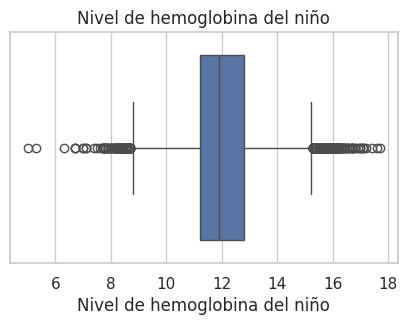

In [9]:
display(base_final["Nivel de hemoglobina del niño"].describe())

plt.subplots(figsize=(5, 3))
sns.boxplot(data=base_final, x="Nivel de hemoglobina del niño")
plt.title("Nivel de hemoglobina del niño")
plt.show()


In [10]:
# --- Regla IQR ---
q1 = base_final["Nivel de hemoglobina del niño"].quantile(0.25)
q3 = base_final["Nivel de hemoglobina del niño"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Límite inferior (IQR):", round(limite_inferior, 2))
print("Límite superior (IQR):", round(limite_superior, 2))

candidatos_iqr = base_final[
    (base_final["Nivel de hemoglobina del niño"] < limite_inferior) |
    (base_final["Nivel de hemoglobina del niño"] > limite_superior)
]
print("Candidatos IQR:", candidatos_iqr.shape[0])

# --- Comparación con z-score ---
media = base_final["Nivel de hemoglobina del niño"].mean()
desv = base_final["Nivel de hemoglobina del niño"].std()
z = (base_final["Nivel de hemoglobina del niño"] - media) / desv

candidatos_z = base_final[z.abs() > 3]
print("Candidatos |z| > 3:", candidatos_z.shape[0])


Límite inferior (IQR): 8.8
Límite superior (IQR): 15.2
Candidatos IQR: 377
Candidatos |z| > 3: 105


### Decisión: NO se elimina ni se trata como error

**Los valores bajos de hemoglobina NO son ruido ni error de medición - son exactamente la población que el proyecto busca identificar.** El objetivo del Hito 1 es segmentar niños según su riesgo de anemia; los casos con hemoglobina más baja (candidatos a "atípicos" según IQR/z-score) corresponden a anemia moderada/grave, ya documentados como reales en la sección de EDA del Hito 1.

Tratar estos valores como outliers a eliminar **destruiría la señal que el clustering necesita encontrar**. Aquí "detectar un candidato a atípico" y "tratarlo como error" son decisiones completamente distintas, aquí el argumento es más fuerte: eliminar estos casos no solo pierde información, sesga el análisis en contra del objetivo mismo del proyecto.



## 3. Variables derivadas

Se proponen 2 variables, ambas con significado claro para la unidad de análisis (par madre-niño) y relevantes para el problema de segmentación.


In [11]:
# 3.1 Diferencia de hemoglobina madre-niño
# Justificación: la matriz de correlación del Hito 1 mostró que la hemoglobina materna
# es la variable de contexto más asociada a la del niño (0.51). La diferencia (no solo
# el valor absoluto de cada una por separado) puede capturar mejor un patrón de riesgo
# relativo -- ej. un niño con hemoglobina baja Y una madre con hemoglobina alta representa
# un perfil distinto a un niño con hemoglobina baja y madre también con hemoglobina baja.
base_final["diferencia_hemoglobina"] = (
    base_final["Nivel de hemoglobina del niño"] - base_final["Nivel de hemoglobina de la madre"]
)

display(base_final[["Nivel de hemoglobina de la madre","Nivel de hemoglobina del niño","diferencia_hemoglobina"]].describe())


,Nivel de hemoglobina de la madre,Nivel de hemoglobina del niño,diferencia_hemoglobina
count,18290.000000,18290.000000,18290.000000
mean,13.294811,11.986774,-1.308037
std,1.578062,1.319282,1.451433
min,5.000000,5.000000,-9.100000
25%,12.300000,11.200000,-2.200000
50%,13.200000,11.900000,-1.300000
75%,14.300000,12.800000,-0.400000
max,20.600000,17.700000,9.500000


In [12]:
# 3.2 Indicador binario: ¿el niño tiene algún nivel de anemia?
# Justificación: "Nivel de anemia del niño" ya es una variable ordinal útil (Grave/Moderada/
# Leve/Sin anemia), pero para poder VALIDAR los clusters resultantes más adelante (comparar
# "% con anemia" entre grupos) conviene tener también una versión binaria simple.
# Se respeta el faltante: un NaN en la variable original se mantiene NaN aquí (no se asume
# "Sin anemia" para quien no tiene dato, sería inventar información).
mapa_anemia_bin = {"Grave": 1, "Moderada": 1, "Leve": 1, "Sin anemia": 0}
base_final["tiene_anemia_bin"] = base_final["Nivel de anemia del niño"].map(mapa_anemia_bin)

display(base_final[["Nivel de anemia del niño", "tiene_anemia_bin"]].value_counts(dropna=False))


,,count
Nivel de anemia del niño,tiene_anemia_bin,
Sin anemia,0.0,11636
Leve,1.0,3910
NaN,NaN,1590
Moderada,1.0,1134
Grave,1.0,20



## 4. Discretización

**Variable elegida:** `Edad en meses del niño`.

**Justificación de los puntos de corte:** no son arbitrarios, provienen directamente de un hallazgo del Hito 1: los casos de anemia moderada/grave se concentran casi exclusivamente entre los 6 y 24 meses de vida (periodo de introducción de alimentación complementaria), y prácticamente desaparecen después de los 30-40 meses. Los cortes `0-6 / 6-24 / 24-60` no son percentiles genéricos: representan la ventana etaria de riesgo identificada, útil para que un futuro cluster pueda alinearse con esa política de intervención (ej. "priorizar suplementación de hierro en el grupo 6-24 meses").


In [13]:
base_final["grupo_edad_meses"] = pd.cut(
    base_final["Edad en meses del niño"],
    bins=[0, 6, 24, 60],
    labels=["0-6 meses", "6-24 meses", "24-60 meses"],
    include_lowest=True
)

display(base_final[["Edad en meses del niño", "grupo_edad_meses"]].head())
display(base_final["grupo_edad_meses"].value_counts())


,Edad en meses del niño,grupo_edad_meses
0,29.0,24-60 meses
1,13.0,6-24 meses
2,45.0,24-60 meses
3,13.0,6-24 meses
4,17.0,6-24 meses


,count
grupo_edad_meses,
24-60 meses,11066
6-24 meses,5645
0-6 meses,1579


In [14]:
# grupo_edad_meses es ordinal (0-6 < 6-24 < 24-60): se codifica respetando el orden,
# no con one-hot -- igual que grupo_edad_ord en el caso clínico.
orden_edad = {"0-6 meses": 0, "6-24 meses": 1, "24-60 meses": 2}
base_final["grupo_edad_ord"] = base_final["grupo_edad_meses"].map(orden_edad)

display(base_final[["grupo_edad_meses", "grupo_edad_ord"]].drop_duplicates())


,grupo_edad_meses,grupo_edad_ord
0,24-60 meses,2
1,6-24 meses,1
16,0-6 meses,0



## 5. Codificación de variables categóricas

Repaso rápido, ya con las nuevas variables incorporadas.


In [15]:
# Binaria: Sexo del niño
base_final["sexo_bin"] = base_final["Sexo del niño"].map({"Hombre": 0, "Mujer": 1})

# Ordinal: Nivel educativo de la madre -- SÍ tiene un orden natural
# (Sin educación < Primaria < Secundaria < Superior), por eso se codifica como orden,
# no con one-hot. "No sabe" no encaja en ese orden -> se deja como NaN explícito.
orden_educacion = {"Sin educación": 0, "Primaria": 1, "Secundaria": 2, "Superior": 3, "No sabe": np.nan}
base_final["educacion_madre_ord"] = base_final["Nivel educativo de la madre"].map(orden_educacion)

display(base_final[["Sexo del niño","sexo_bin","Nivel educativo de la madre","educacion_madre_ord"]].head())


,Sexo del niño,sexo_bin,Nivel educativo de la madre,educacion_madre_ord
0,Mujer,1,Secundaria,2.0
1,Hombre,0,Superior,3.0
2,Mujer,1,Primaria,1.0
3,Mujer,1,Secundaria,2.0
4,Hombre,0,Secundaria,2.0


**Sobre `Región del hogar`: decisión de NO aplicar one-hot encoding para la matriz de clustering:**

Tiene 25 categorías; un one-hot generaría 25 columnas nuevas que dominarían la matriz y distorsionarían la distancia usada por K-means (el mismo riesgo que ya se advirtió con `distrito` en el caso clínico, pero aquí a mayor escala). Como el proyecto ya tiene su propia forma de aprovechar la región, la tabla resumen de la Sección 8, no es necesario forzarla dentro de la matriz de clustering. Se conserva en `base_final` para reportes, pero se excluye de `matriz_analitica`.



## 6. Escalamiento

**Por qué sí hace falta aquí :** el Hito 1 ya declaró como próximo paso aplicar **PCA + K-means**. Ambas técnicas son sensibles a la magnitud de las variables: PCA maximiza varianza, así que una variable en una escala más grande (ej. `Altura en centímetros del niño`, que va hasta ~110) dominaría artificialmente sobre una en escala pequeña (ej. `Nivel de hemoglobina del niño`, entre 4 y 20) aunque ambas sean igual de relevantes.

**Min–Max vs. z-score - se elige z-score:** PCA se basa en varianza, y z-score es la preparación estándar para PCA porque centra cada variable en 0 con desviación 1, haciendo la varianza comparable entre variables de unidades distintas (kg, cm, g/dl, años). Min–Max solo remapea el rango a [0,1], pero no iguala la varianza entre variables, es más apropiado cuando el algoritmo posterior es sensible al rango absoluto (ej. redes neuronales), no a la varianza.

**Qué NO se escala:** `sexo_bin`, `tiene_anemia_bin` (binarias, ya están en una escala comparable de por sí), `grupo_edad_ord` y `educacion_madre_ord` (representan orden, no magnitud. Escalar un código ordinal no tiene interpretación real, mismo argumento que `grupo_edad_ord` en el caso clínico).


In [16]:
variables_escalar = [
    "Edad de la madre en años",
    "Peso de la madre",
    "Talla de la madre",
    "Nivel de hemoglobina de la madre",
    "Peso en kilogramos del niño",
    "Altura en centímetros del niño",
    "Nivel de hemoglobina del niño",
    "diferencia_hemoglobina"
]

# Revisión previa de escalas (para sustentar la decisión de arriba con evidencia)
base_final[variables_escalar].describe().T[["min", "max", "mean", "std"]]


,min,max,mean,std
Edad de la madre en años,13.0,49.0,30.917277,6.963877
Peso de la madre,32.9,138.7,66.353532,13.010319
Talla de la madre,129.4,188.5,152.753696,5.622808
Nivel de hemoglobina de la madre,5.0,20.6,13.294811,1.578062
Peso en kilogramos del niño,2.2,39.8,12.951520,3.901213
Altura en centímetros del niño,36.7,122.8,87.048141,13.550440
Nivel de hemoglobina del niño,5.0,17.7,11.986774,1.319282
diferencia_hemoglobina,-9.1,9.5,-1.308037,1.451433



## 7. Matriz analítica actualizada

Se conserva `Identificación Cuestionario Individual` aparte, para trazabilidad. No se incluye `Región del hogar` (justificado arriba), ni variables descriptivas del hogar/registro que no son características analíticas para el clustering (`Año_madre`, `Año_nino`, `Resultado de medición de la madre`, `Número de orden...`).


In [17]:
id_par = base_final["Identificación Cuestionario Individual"].copy()

columnas_analiticas = [
    "Edad de la madre en años",
    "Peso de la madre",
    "Talla de la madre",
    "Nivel de hemoglobina de la madre",
    "educacion_madre_ord",
    "Peso en kilogramos del niño",
    "Altura en centímetros del niño",
    "Nivel de hemoglobina del niño",
    "sexo_bin",
    "grupo_edad_ord",
    "diferencia_hemoglobina",
    "tiene_anemia_bin"
]

matriz_analitica = base_final[columnas_analiticas].copy()

# Aplicamos z-score SOLO a las variables continuas seleccionadas en la sección 6
# (las binarias/ordinales no se tocan).
estandarizador = StandardScaler()
matriz_analitica_escalada = matriz_analitica.copy()
matriz_analitica_escalada[variables_escalar] = estandarizador.fit_transform(
    matriz_analitica_escalada[variables_escalar]
)

print("Matriz sin escalar:")
display(matriz_analitica.head())

print("Matriz escalada (z-score):")
display(matriz_analitica_escalada.head())


Matriz sin escalar:


,Edad de la madre en años,Peso de la madre,Talla de la madre,Nivel de hemoglobina de la madre,educacion_madre_ord,Peso en kilogramos del niño,Altura en centímetros del niño,Nivel de hemoglobina del niño,sexo_bin,grupo_edad_ord,diferencia_hemoglobina,tiene_anemia_bin
0,26.0,58.6,154.5,15.1,2.0,13.1,89.4,12.7,1,2,-2.4,0.0
1,38.0,50.4,151.7,12.8,3.0,11.4,76.1,12.3,0,1,-0.5,0.0
2,44.0,57.1,148.7,15.4,1.0,13.9,95.9,14.0,1,2,-1.4,0.0
3,42.0,83.8,150.5,13.7,2.0,8.1,70.3,12.4,1,1,-1.3,0.0
4,30.0,68.2,159.3,13.4,2.0,11.5,81.1,11.2,0,1,-2.2,1.0


Matriz escalada (z-score):


,Edad de la madre en años,Peso de la madre,Talla de la madre,Nivel de hemoglobina de la madre,educacion_madre_ord,Peso en kilogramos del niño,Altura en centímetros del niño,Nivel de hemoglobina del niño,sexo_bin,grupo_edad_ord,diferencia_hemoglobina,tiene_anemia_bin
0,-0.706131,-0.595969,0.310584,1.143959,2.0,0.038061,0.173568,0.540631,1,2,-0.752355,0.0
1,1.017094,-1.226255,-0.187402,-0.313565,3.0,-0.397713,-0.807977,0.237428,0,1,0.556732,0.0
2,1.878706,-0.711265,-0.720958,1.334071,1.0,0.243131,0.653270,1.526043,1,2,-0.063362,0.0
3,1.591502,1.341008,-0.400824,0.256770,2.0,-1.243627,-1.236019,0.313229,1,1,0.005538,0.0
4,-0.131723,0.141927,1.164273,0.066659,2.0,-0.372079,-0.438975,-0.596382,0,1,-0.614556,1.0



## 8. Tabla resumen a nivel región (usando RECH0)

Aquí es donde region/área sí se aprovecha: no como columna dentro de la matriz de clustering, sino como una **unidad de análisis distinta** (una fila = una región), útil para reportar hallazgos a entidades como MINSA. Mismo patrón `groupby().agg()` que la reconstrucción de unidad de análisis del caso clínico, pero aplicado aquí para cambiar de "par madre-niño" a "región".


In [18]:
resumen_region = (
    base_final
    .groupby(["Región del hogar", "Área de residencia"])
    .agg(
        n_ninos=("Identificación Cuestionario Individual", "size"),
        tasa_anemia=("tiene_anemia_bin", "mean"),
        hemoglobina_promedio_nino=("Nivel de hemoglobina del niño", "mean"),
        hemoglobina_promedio_madre=("Nivel de hemoglobina de la madre", "mean"),
    )
    .reset_index()
)

resumen_region["tasa_anemia"] = (resumen_region["tasa_anemia"] * 100).round(1)
resumen_region[["hemoglobina_promedio_nino","hemoglobina_promedio_madre"]] = (
    resumen_region[["hemoglobina_promedio_nino","hemoglobina_promedio_madre"]].round(2)
)

resumen_region = resumen_region.sort_values("tasa_anemia", ascending=False)
display(resumen_region)


,Región del hogar,Área de residencia,n_ninos,tasa_anemia,hemoglobina_promedio_nino,hemoglobina_promedio_madre
27,Loreto,Rural,328,49.5,10.90,12.03
37,Puno,Rural,172,48.1,13.20,14.89
29,Madre de Dios,Rural,180,42.8,11.12,12.53
31,Moquegua,Rural,62,42.1,12.92,14.18
0,Amazonas,Rural,463,41.8,11.64,12.96
19,Junín,Rural,208,41.4,12.22,13.66
33,Pasco,Rural,180,41.0,12.54,14.11
47,Áncash,Rural,223,41.0,12.73,14.64
39,San Martín,Rural,301,39.6,11.34,12.87
16,Huánuco,Urbano,322,39.3,12.09,13.46


In [19]:
fig = px.bar(
    resumen_region.head(10),
    x="Región del hogar",
    y="tasa_anemia",
    color="Área de residencia",
    barmode="group",
    text="tasa_anemia",
    title="Top 10 regiones con mayor tasa de anemia infantil (%)"
)
fig.show()


**Nota para tu redacción:** esta tabla es la que le daría a MINSA una lista concreta de regiones a priorizar (las de mayor `tasa_anemia`), en vez del promedio nacional único que tenías en el Hito 1 - es el mismo tipo de valor agregado que se buscó con la unidad de análisis "atención" o "medicamento" en el caso clínico: la misma base de datos, resumida a un nivel distinto, responde una pregunta distinta.



## 9. Verificación final

In [20]:
print("Filas de base_final:", base_final.shape[0])
print("Filas de matriz_analitica:", matriz_analitica.shape[0])

print("\nFaltantes en la matriz:")
print(matriz_analitica.isna().sum())

print("\nTipos de datos:")
print(matriz_analitica.dtypes)


Filas de base_final: 18290
Filas de matriz_analitica: 18290

Faltantes en la matriz:
Edad de la madre en años               0
Peso de la madre                       0
Talla de la madre                      0
Nivel de hemoglobina de la madre       0
educacion_madre_ord                    0
Peso en kilogramos del niño            0
Altura en centímetros del niño         0
Nivel de hemoglobina del niño          0
sexo_bin                               0
grupo_edad_ord                         0
diferencia_hemoglobina                 0
tiene_anemia_bin                    1590
dtype: int64

Tipos de datos:
Edad de la madre en años             float64
Peso de la madre                     float64
Talla de la madre                    float64
Nivel de hemoglobina de la madre     float64
educacion_madre_ord                  float64
Peso en kilogramos del niño          float64
Altura en centímetros del niño       float64
Nivel de hemoglobina del niño        float64
sexo_bin                         

## 10. Registro de decisiones

| Elemento | Decisión | Justificación |
|---|---|---|
| RECH0 (región/área) | Incorporar solo para reporte, no para la matriz de clustering | 25 categorías inflarían la matriz vía one-hot; se usa en una tabla resumen separada |
| Outliers de hemoglobina del niño | Conservar, no tratar como error | Son la población de interés del proyecto (casos de anemia real) |
| `diferencia_hemoglobina` | Crear como variable derivada | Captura relación relativa madre-hijo, no solo valores absolutos |
| `tiene_anemia_bin` | Crear como variable derivada | Permite validar clusters después, respetando los faltantes ya identificados |
| `Edad en meses del niño` | Discretizar en 3 grupos (0-6/6-24/24-60) | Cortes basados en el hallazgo real del Hito 1, no en cuantiles genéricos |
| `Nivel educativo de la madre` | Codificar ordinal, no one-hot | Tiene orden natural; "No sabe" no encaja en ese orden y queda como NaN |
| Variables continuas (peso, talla, hemoglobina, diferencia) | Escalar con z-score | Preparación estándar para PCA, próximo paso declarado en el Hito 1 |
| Variables binarias/ordinales | No escalar | Ya están en escala comparable o representan orden, no magnitud |
